In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

BASE_DIR = "/Users/babina/Desktop/Group Software Project/Morphological-Analysis-of-Fruit-Fly-Images/data/Wing vein length/"
EXCEL_NAME = "Ground truth for wing vein length.xlsx"

# Load Excel 
excel_path = os.path.join(BASE_DIR, EXCEL_NAME)
df = pd.read_excel(excel_path)

def fix_filename(name):
    name = str(name).strip()
    if not name.lower().endswith(".tif"):
        name = name + ".TIF"   
    return name

df["Name of the Image"] = df["Name of the Image"].apply(fix_filename)
df.head()

,Name of the Image,wing vein [mm]
0,TE14_zi134_25C_F_wing_MK_2_250912_001.TIF,1.529
1,TE14_zi134_25C_F_wing_MK_3_250912_001.TIF,1.497
2,TE14_zi134_25C_F_wing_MK_8_250912_001.TIF,1.432
3,TE14_zi134_25C_F_wing_2_250731_001.TIF,1.465
4,TE14_zi134_25C_F_wing_3_250731_001.TIF,1.478


In [2]:
df = df.rename(columns={
    "Name of the Image": "filename",
    "wing vein [mm]": "wing_mm"
})

df.head()


,filename,wing_mm
0,TE14_zi134_25C_F_wing_MK_2_250912_001.TIF,1.529
1,TE14_zi134_25C_F_wing_MK_3_250912_001.TIF,1.497
2,TE14_zi134_25C_F_wing_MK_8_250912_001.TIF,1.432
3,TE14_zi134_25C_F_wing_2_250731_001.TIF,1.465
4,TE14_zi134_25C_F_wing_3_250731_001.TIF,1.478


First image path: /Users/babina/Desktop/Group Software Project/Morphological-Analysis-of-Fruit-Fly-Images/data/Wing vein length/TE14_zi134_25C_F_wing_MK_2_250912_001.TIF
Shape: (1024, 1360, 3) dtype: uint8 min: 58 max: 237


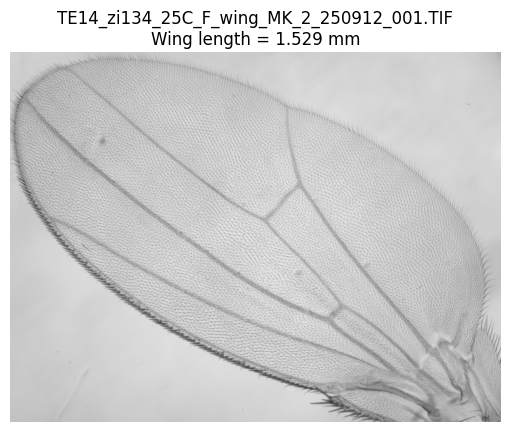

In [3]:
# Pick the first image from the table
first_name = df.loc[0, "filename"]
img_path = os.path.join(BASE_DIR, first_name)
print("First image path:", img_path)

# Read as grayscale with original bit depth
img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
print("Shape:", img.shape, "dtype:", img.dtype,
      "min:", np.min(img), "max:", np.max(img))

# OpenCV loads as BGR / grayscale; matplotlib expects RGB or grayscale
plt.imshow(img, cmap="gray")
plt.title(f"{first_name}\nWing length = {df.loc[0, 'wing_mm']} mm")
plt.axis("off")
plt.show()

plt.show()

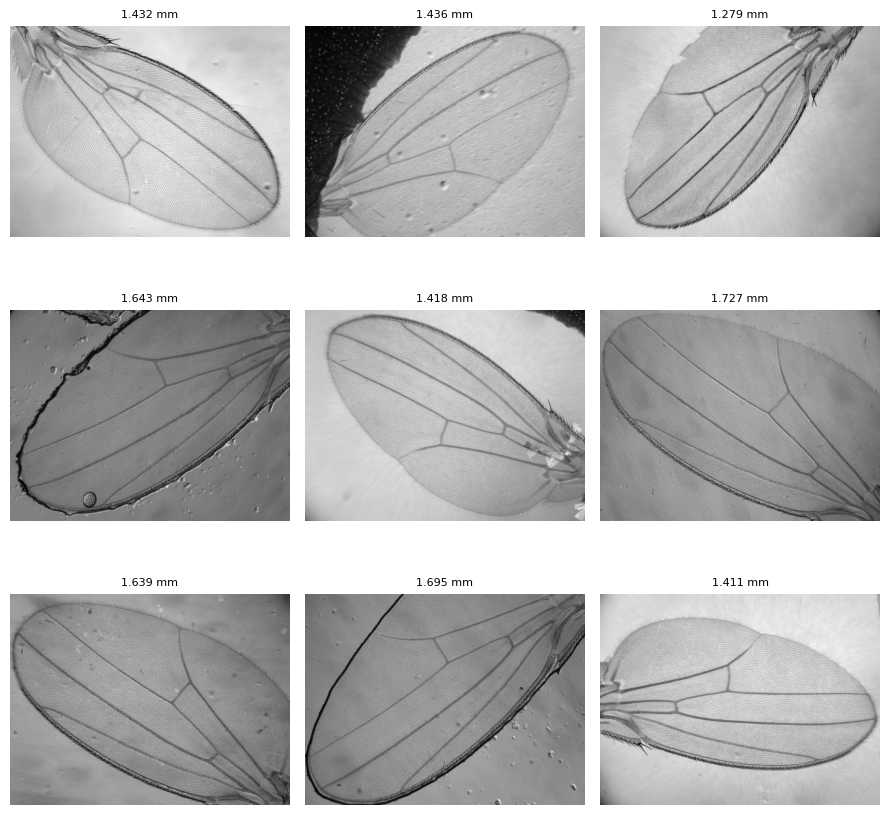

In [4]:
# Sample 9 random rows
sample = df.sample(9, random_state=0).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for i, row in sample.iterrows():
    img_path = os.path.join(BASE_DIR, row["filename"])
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    r, c = divmod(i, 3)
    ax = axes[r, c]
    ax.imshow(img_norm, cmap="gray")
    ax.set_title(f"{row['wing_mm']:.3f} mm", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


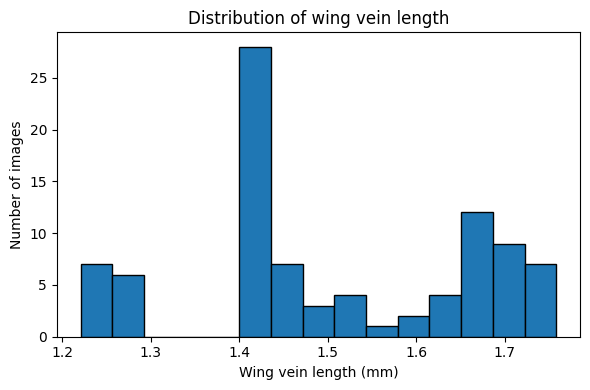

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(df["wing_mm"], bins=15, edgecolor="black")
plt.xlabel("Wing vein length (mm)")
plt.ylabel("Number of images")
plt.title("Distribution of wing vein length")
plt.tight_layout()
plt.show()


In [6]:

TARGET_SIZE = (256, 256)  

def load_raw_wing(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
   
    img = img.astype("float32")
    return img

def normalize_contrast(img):
    # min-max normalize to [0,1] for processing
    min_v, max_v = img.min(), img.max()
    if max_v - min_v < 1e-6:
        return np.zeros_like(img)
    img_norm = (img - min_v) / (max_v - min_v)
    return img_norm

def center_crop(img, crop_frac=0.8):
    """Simple central crop to remove borders; keeps crop_frac of height/width."""
    h, w = img.shape[:2]
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    y0 = (h - ch) // 2
    x0 = (w - cw) // 2
    return img[y0:y0+ch, x0:x0+cw]

def resize_image(img, size=TARGET_SIZE):
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

def preprocess_wing(path, crop=True):
    img = load_raw_wing(path)
    img = normalize_contrast(img)
    if crop:
        img = center_crop(img, crop_frac=0.8)
    img = resize_image(img, size=TARGET_SIZE)
    return img


In [8]:
X = []
y = []
missing = []

for idx, row in df.iterrows():
    fname = row["filename"]
    path = os.path.join(BASE_DIR, fname)

    if not os.path.exists(path):
        print(f"Missing file at row {idx}: {fname}")
        missing.append(fname)
        continue  

    img_proc = preprocess_wing(path, crop=True)
    X.append(img_proc)
    y.append(row["wing_mm"])

X = np.array(X, dtype="float32")
y = np.array(y, dtype="float32")

print("Preprocessed dataset shape:", X.shape, "targets shape:", y.shape)
print("Total missing files:", len(missing))


Missing file at row 31: TE14_zi134_25C_18C_F_wing_14_250815_001.TIF
Missing file at row 34: TE14_ZI134_18C_F_MK_3TE14_zi134_18C_F_wing_MK_3_250912_001.TIF
Preprocessed dataset shape: (88, 256, 256, 3) targets shape: (88,)
Total missing files: 2


In [9]:
def preprocess_wing(path, crop=True):
    img = load_raw_wing(path)        # read TIFF -> float32
    img = normalize_contrast(img)    # scale to [0,1]
    if crop:
        img = center_crop(img, crop_frac=0.8)
    img = resize_image(img, size=(256, 256))
    return img


X = []
y = []
used_filenames = []

for _, row in df.iterrows():
    fname = row["filename"]
    path = os.path.join(BASE_DIR, fname)

    if not os.path.exists(path):
        # skip rows where the file is not found
        continue

    img_proc = preprocess_wing(path, crop=True)
    X.append(img_proc)
    y.append(row["wing_mm"])
    used_filenames.append(fname)

X = np.array(X, dtype="float32")  # (N, 256, 256)
y = np.array(y, dtype="float32")  # (N,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of images actually used:", len(used_filenames))


X shape: (88, 256, 256, 3)
y shape: (88,)
Number of images actually used: 88


In [10]:
N = X.shape[0]
X_flat = X.reshape(N, -1)  # shape: (N, 256*256)
print("Flattened feature shape:", X_flat.shape)


Flattened feature shape: (88, 196608)


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.3f} mm")
print(f"Test R²: {r2:.3f}")


Test MAE: 0.088 mm
Test R²: 0.196


In [12]:
results = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})
results["abs_error"] = (results["y_true"] - results["y_pred"]).abs()
results.sort_values("abs_error").head(10)

,y_true,y_pred,abs_error
10,1.408,1.410230,0.002230
17,1.433,1.421865,0.011135
2,1.653,1.640910,0.012090
1,1.529,1.545960,0.016960
14,1.421,1.438165,0.017165
11,1.410,1.427635,0.017635
4,1.464,1.432955,0.031045
15,1.418,1.464235,0.046235
6,1.405,1.453075,0.048075
13,1.411,1.482480,0.071480


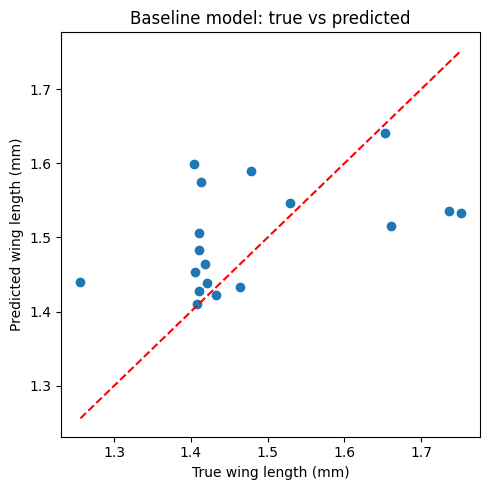

In [13]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("True wing length (mm)")
plt.ylabel("Predicted wing length (mm)")
plt.title("Baseline model: true vs predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.tight_layout()
plt.show()
